# Laboratorio 7: Spark MLlib

## Inciso 4. Segmentacion de perfiles mediante KMeans

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

**Datos.** El cuaderno lee `processed/eneic_2025.parquet`, la poblacion analitica de 2025 (asalariados de 15 anios o mas con salario positivo) que se preparo en el inciso 1. Ese archivo se genera desde los cinco Excel de la ENEIC que estan en esta carpeta con `.venv/bin/python -m src.datos`. Si no existe, `datos.cargar` lo construye solo (tarda unos dos minutos).

**Entorno.** `python3 -m venv .venv && .venv/bin/python -m pip install -r requirements.txt` dentro de `Lab7/`. Spark 3.5.9 en modo local.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.sql import functions as F

from src import config, datos

config.preparar_directorios()
pd.set_option("display.float_format", "{:,.3f}".format)

spark = datos.iniciar_spark()
df = datos.cargar(spark, 2025).cache()
print("Registros 2025:", df.count())

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Registros 2025: 53025


### 4.1 Variables y estandarizacion

La pregunta del contexto es que perfiles de asalariados aparecen segun su edad, antiguedad y jornada. Por eso la segmentacion principal usa tres variables numericas:

- `edad`: etapa de la vida laboral.
- `antiguedad`: anios en el empleo actual (anios + meses / 12).
- `horas_semanales`: jornada habitual de la ocupacion principal.

Las categoricas (educacion, categoria ocupacional, dominio) no entran al KMeans. KMeans mide distancia euclidiana y una variable one-hot solo toma 0 o 1, asi que la distancia entre categorias no tiene un significado real y terminaria dominando o distorsionando los grupos. Se usan despues para describir los clusters.

El salario tampoco entra en la version principal; en la seccion 4.4 se prueba incluirlo y se compara.

Las tres variables estan en escalas distintas (edad de 15 a 89, antiguedad de 0 a 70, horas de 1 a 126). Sin estandarizar, la variable con mayor varianza decidiria los grupos. `StandardScaler` con `withMean=True` y `withStd=True` deja cada una con media 0 y desviacion 1, de modo que las tres pesan lo mismo en la distancia.

Todo se calcula con los 53,025 registros de 2025, sin ponderar por `FACTOR`.

In [2]:
VARIABLES = ["edad", "antiguedad", "horas_semanales"]


def estandarizar(df, variables):
    """Ensambla las variables en un vector y las lleva a media 0 y desviacion 1."""
    ensamblador = VectorAssembler(inputCols=variables, outputCol="crudo")
    escalador = StandardScaler(inputCol="crudo", outputCol="features", withMean=True, withStd=True)
    modelo = Pipeline(stages=[ensamblador, escalador]).fit(df)
    return modelo.transform(df).cache()


def evaluar_k(base, ks=(2, 3, 4, 5)):
    """Ajusta KMeans para cada K y devuelve silueta, costo y tamanio de clusters."""
    evaluador = ClusteringEvaluator(featuresCol="features", metricName="silhouette")
    filas, modelos_k = [], {}
    total = base.count()
    for k in ks:
        modelo = KMeans(k=k, seed=config.SEMILLA, featuresCol="features", maxIter=50).fit(base)
        pred = modelo.transform(base)
        tamanios = [r["count"] for r in pred.groupBy("prediction").count().collect()]
        filas.append({
            "k": k,
            "silueta": evaluador.evaluate(pred),
            "costo_intra": modelo.summary.trainingCost,
            "cluster_mas_chico": min(tamanios),
            "pct_mas_chico": 100 * min(tamanios) / total,
        })
        modelos_k[k] = modelo
    return pd.DataFrame(filas), modelos_k


base = estandarizar(df, VARIABLES)
base.select("crudo", "features").show(3, truncate=False)

+----------------+-------------------------------------------------------------+
|crudo           |features                                                     |
+----------------+-------------------------------------------------------------+
|[42.0,20.0,1.0] |[0.5038386390039737,1.8440991857519686,-2.431906213821356]   |
|[41.0,0.25,25.0]|[0.42987907409792947,-0.6779231198019624,-1.1436895795001762]|
|[38.0,20.0,36.0]|[0.20800037937979668,1.8440991857519686,-0.5532569554363023] |
+----------------+-------------------------------------------------------------+
only showing top 3 rows



### 4.2 Eleccion de K

Se prueban K = 2, 3, 4 y 5 con semilla fija. El criterio del grupo combina tres cosas:

1. **Codo del costo intra-cluster** (`trainingCost`, suma de distancias al cuadrado a su centro): se busca el K despues del cual agregar un cluster ya casi no reduce el costo.
2. **Silueta** (`ClusteringEvaluator`): que tan separado esta cada punto de otro cluster frente a su propio cluster, de -1 a 1. Se pide que sea razonable (mayor a 0.45), no necesariamente la maxima, porque la silueta casi siempre favorece K = 2.
3. **Tamanio minimo e interpretabilidad**: ningun cluster debajo del 5% de los registros y que cada grupo se pueda describir con palabras.

In [3]:
resultados, modelos_k = evaluar_k(base)
resultados["reduccion_costo_pct"] = -100 * resultados["costo_intra"].pct_change()
resultados

,k,silueta,costo_intra,cluster_mas_chico,pct_mas_chico,reduccion_costo_pct
0,2,0.555,"106,717.386",14586,27.508,NaN
1,3,0.472,"83,608.004",10115,19.076,21.655
2,4,0.474,"64,437.146",6858,12.934,22.929
3,5,0.491,"56,848.447",2615,4.932,11.777


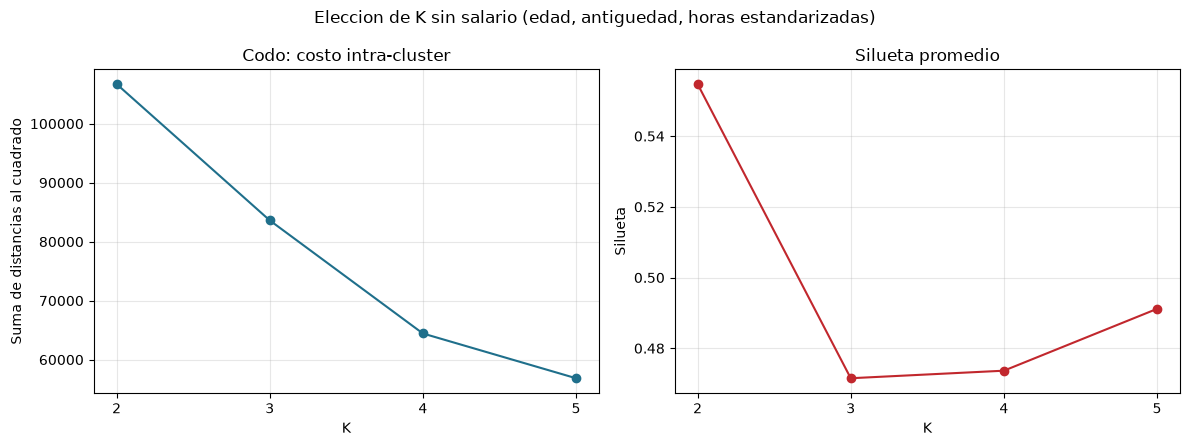

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

ejes[0].plot(resultados["k"], resultados["costo_intra"], marker="o", color=config.COLORES["principal"])
ejes[0].set_title("Codo: costo intra-cluster")
ejes[0].set_xlabel("K")
ejes[0].set_ylabel("Suma de distancias al cuadrado")

ejes[1].plot(resultados["k"], resultados["silueta"], marker="o", color=config.COLORES["modelo"])
ejes[1].set_title("Silueta promedio")
ejes[1].set_xlabel("K")
ejes[1].set_ylabel("Silueta")

for eje in ejes:
    eje.set_xticks(resultados["k"])
    eje.grid(alpha=0.3)

fig.suptitle("Eleccion de K sin salario (edad, antiguedad, horas estandarizadas)")
fig.tight_layout()
fig.savefig(config.FIGURAS / "04_eleccion_k.png", dpi=120)
plt.show()

Para decidir no basta con las metricas: tambien importa que separa cada K. La tabla muestra, para cada K, las medias de cada cluster en unidades originales.

In [5]:
def medias_por_cluster(modelos_k, base):
    """Medias de edad, antiguedad y horas por cluster para cada K probado."""
    tablas = []
    for k, modelo_k in modelos_k.items():
        tabla = (modelo_k.transform(base).groupBy("prediction")
                 .agg(F.count("*").alias("n"), *[F.mean(v).alias(v) for v in VARIABLES])
                 .orderBy("edad").toPandas())
        tabla.insert(0, "k", k)
        tablas.append(tabla.drop(columns="prediction"))
    return pd.concat(tablas, ignore_index=True)


medias_por_cluster(modelos_k, base)

,k,n,edad,antiguedad,horas_semanales
0,2,38439,29.079,2.425,48.206
1,2,14586,51.286,13.818,41.305
2,3,31017,29.993,2.459,39.907
3,3,10115,31.143,3.262,73.147
4,3,11893,52.175,15.596,40.172
5,4,24265,25.938,2.432,40.586
6,4,9256,30.127,3.408,74.165
7,4,12646,48.669,4.076,39.760
8,4,6858,49.886,22.259,41.028
9,5,24100,25.767,2.078,41.096


**Lectura.**

- K = 2 tiene la silueta mas alta (0.555), pero solo separa a los jovenes con poca antiguedad (29 anios de edad y 2.4 de antiguedad en promedio) de los mayores con mas antiguedad (51 y 13.8). Es una division demasiado gruesa: esconde por completo a quienes trabajan jornadas muy largas.
- El costo baja 21.7% de K = 2 a 3 y 22.9% de 3 a 4, pero solo 11.8% de 4 a 5. El codo esta en K = 4: a partir de ahi un cluster adicional aporta la mitad de lo que aportaba el anterior.
- K = 3 junta en un solo grupo a todos los mayores (52 anios, 15.6 de antiguedad promedio), mezclando a quienes llevan dos decadas en su empleo con quienes acaban de entrar. K = 4 los separa en dos grupos de edad parecida (49 y 50 anios) pero con 4.1 y 22.3 anios de antiguedad.
- La silueta de K = 4 (0.474) es practicamente la de K = 3 (0.472) y supera el umbral de 0.45. K = 5 sube a 0.491, pero lo logra partiendo a los veteranos y deja un grupo de 2,615 registros (4.9%), debajo del minimo de 5%.

**Se elige K = 4**: esta en el codo del costo, tiene una silueta aceptable, todos sus clusters superan el 12% de los registros y da cuatro perfiles que se pueden nombrar.

### 4.3 Perfiles con el K elegido

Se describe cada cluster en las unidades originales: medias y medianas de las variables usadas, y como variables externas (que no participaron en el agrupamiento) el salario, la categoria ocupacional, la educacion y el dominio. Las medianas se calculan con `percentile` exacto sobre todos los registros.

In [6]:
K_ELEGIDO = 4
modelo = modelos_k[K_ELEGIDO]
segmentado = modelo.transform(base).withColumnRenamed("prediction", "cluster").cache()

perfil = (segmentado.groupBy("cluster")
          .agg(F.count("*").alias("n"),
               F.mean("edad").alias("edad_media"),
               F.mean("antiguedad").alias("antiguedad_media"),
               F.expr("percentile(antiguedad, 0.5)").alias("antiguedad_mediana"),
               F.mean("horas_semanales").alias("horas_media"),
               F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
               F.mean("salario_mensual").alias("salario_medio"))
          .orderBy("cluster")
          .toPandas())
perfil["pct"] = 100 * perfil["n"] / perfil["n"].sum()
perfil

,cluster,n,edad_media,antiguedad_media,antiguedad_mediana,horas_media,salario_mediano,salario_medio,pct
0,0,12646,48.669,4.076,3.000,39.760,"3,000.000","3,540.644",23.849
1,1,6858,49.886,22.259,20.000,41.028,"3,800.000","4,682.594",12.934
2,2,24265,25.938,2.432,1.250,40.586,"3,000.000","3,078.889",45.761
3,3,9256,30.127,3.408,2.000,74.165,"3,000.000","3,223.569",17.456


Los numeros de cluster que asigna KMeans son arbitrarios. Para que el nombre no dependa de ese numero, cada cluster se nombra con una regla sobre sus centros: el de mas horas es la jornada extendida, entre los demas el de mas antiguedad son los veteranos, el de menor edad los jovenes de ingreso reciente y el que queda los adultos con poca antiguedad.

In [7]:
def nombrar_clusters(perfil):
    """Asigna un nombre a cada cluster segun sus medias, no segun su numero."""
    restantes = perfil.copy()
    nombres = {}
    for columna, nombre, mayor in [
        ("horas_media", "Jornada extendida", True),
        ("antiguedad_media", "Veteranos con antiguedad larga", True),
        ("edad_media", "Jovenes de ingreso reciente", False),
    ]:
        fila = restantes.loc[restantes[columna].idxmax() if mayor else restantes[columna].idxmin()]
        nombres[int(fila["cluster"])] = nombre
        restantes = restantes.drop(fila.name)
    for cluster in restantes["cluster"]:
        nombres[int(cluster)] = "Adultos con poca antiguedad"
    return nombres


NOMBRES = nombrar_clusters(perfil)
perfil.insert(1, "perfil", perfil["cluster"].map(NOMBRES))
perfil

,cluster,perfil,n,edad_media,antiguedad_media,antiguedad_mediana,horas_media,salario_mediano,salario_medio,pct
0,0,Adultos con poca antiguedad,12646,48.669,4.076,3.000,39.760,"3,000.000","3,540.644",23.849
1,1,Veteranos con antiguedad larga,6858,49.886,22.259,20.000,41.028,"3,800.000","4,682.594",12.934
2,2,Jovenes de ingreso reciente,24265,25.938,2.432,1.250,40.586,"3,000.000","3,078.889",45.761
3,3,Jornada extendida,9256,30.127,3.408,2.000,74.165,"3,000.000","3,223.569",17.456


In [8]:
def composicion(df, columna):
    """Porcentaje de cada categoria dentro de cada cluster (filas suman 100)."""
    tabla = (df.groupBy("cluster").pivot(columna).count().fillna(0)
             .orderBy("cluster").toPandas().set_index("cluster"))
    tabla = 100 * tabla.div(tabla.sum(axis=1), axis=0)
    tabla.columns = [config.ETIQUETAS[columna].get(c, c) for c in tabla.columns]
    tabla.index = [NOMBRES[i] for i in tabla.index]
    return tabla


composicion(segmentado, "categoria_ocupacional")

,Gobierno,Empresa privada,Jornalero o peon,Servicio domestico
Adultos con poca antiguedad,13.989,46.608,27.305,12.099
Veteranos con antiguedad larga,31.379,40.376,22.339,5.906
Jovenes de ingreso reciente,7.999,56.868,29.236,5.897
Jornada extendida,7.703,67.416,19.047,5.834


In [9]:
composicion(segmentado, "nivel_educativo")

,Ninguno,Preprimaria,Primaria,Basico,Diversificado,Superior,Maestria,Doctorado
Adultos con poca antiguedad,14.147,1.162,36.502,10.565,21.841,13.166,2.459,0.158
Veteranos con antiguedad larga,13.021,1.137,27.792,8.297,25.109,21.654,2.479,0.510
Jovenes de ingreso reciente,3.717,0.631,26.013,17.849,37.643,13.097,1.039,0.012
Jornada extendida,4.440,0.875,32.282,21.748,34.929,5.294,0.411,0.022


In [10]:
composicion(segmentado, "dominio")

,Urbano metropolitano,Resto urbano,Rural nacional
Adultos con poca antiguedad,47.066,34.904,18.029
Veteranos con antiguedad larga,44.109,39.181,16.710
Jovenes de ingreso reciente,41.067,37.156,21.776
Jornada extendida,33.816,43.529,22.656


Para ver los grupos se dibujan los centros estandarizados y una muestra de 5,000 registros. La muestra solo sirve para graficar; las tablas de arriba usan todos los registros.

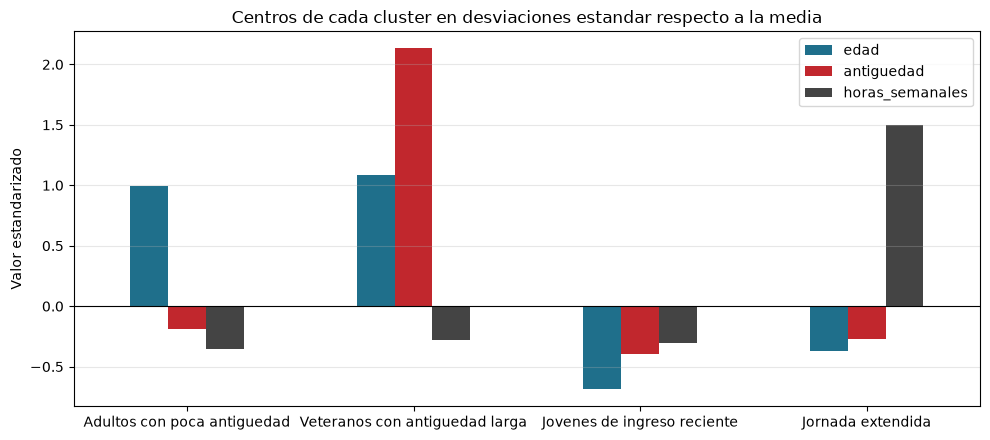

In [11]:
centros = pd.DataFrame(modelo.clusterCenters(), columns=VARIABLES)
centros.index = [NOMBRES[i] for i in range(K_ELEGIDO)]

fig, eje = plt.subplots(figsize=(10, 4.5))
centros.plot.bar(ax=eje, color=[config.COLORES["principal"], config.COLORES["modelo"], config.COLORES["gris"]])
eje.axhline(0, color="black", linewidth=0.8)
eje.set_title("Centros de cada cluster en desviaciones estandar respecto a la media")
eje.set_xlabel("")
eje.set_ylabel("Valor estandarizado")
eje.tick_params(axis="x", rotation=0)
eje.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIGURAS / "04_centros.png", dpi=120)
plt.show()

Registros en la muestra para graficar: 4970


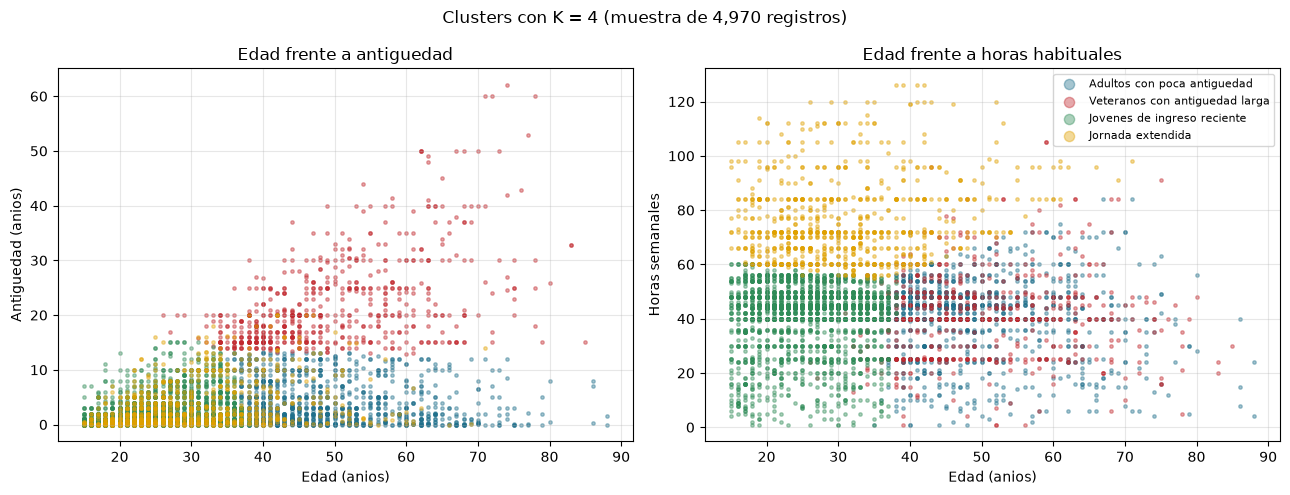

In [12]:
fraccion = min(1.0, 5000 / segmentado.count())
muestra = (segmentado.sample(fraction=fraccion, seed=config.SEMILLA)
           .select("cluster", *VARIABLES).limit(5000).toPandas())
print("Registros en la muestra para graficar:", len(muestra))

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for cluster in range(K_ELEGIDO):
    parte = muestra[muestra["cluster"] == cluster]
    color = config.COLORES["clusters"][cluster]
    ejes[0].scatter(parte["edad"], parte["antiguedad"], s=6, alpha=0.4, color=color, label=NOMBRES[cluster])
    ejes[1].scatter(parte["edad"], parte["horas_semanales"], s=6, alpha=0.4, color=color, label=NOMBRES[cluster])

ejes[0].set_xlabel("Edad (anios)")
ejes[0].set_ylabel("Antiguedad (anios)")
ejes[0].set_title("Edad frente a antiguedad")
ejes[1].set_xlabel("Edad (anios)")
ejes[1].set_ylabel("Horas semanales")
ejes[1].set_title("Edad frente a horas habituales")
for eje in ejes:
    eje.grid(alpha=0.3)
ejes[1].legend(markerscale=3, fontsize=8, loc="upper right")
fig.suptitle(f"Clusters con K = {K_ELEGIDO} (muestra de {len(muestra):,} registros)")
fig.tight_layout()
fig.savefig(config.FIGURAS / "04_clusters_muestra.png", dpi=120)
plt.show()

**Perfiles con K = 4 (53,025 asalariados de 2025):**

| Perfil | Registros | Edad media | Antiguedad media | Horas media | Salario mediano |
|---|---|---|---|---|---|
| Jovenes de ingreso reciente | 24,265 (45.8%) | 25.9 | 2.4 | 40.6 | Q3,000 |
| Adultos con poca antiguedad | 12,646 (23.8%) | 48.7 | 4.1 | 39.8 | Q3,000 |
| Jornada extendida | 9,256 (17.5%) | 30.1 | 3.4 | 74.2 | Q3,000 |
| Veteranos con antiguedad larga | 6,858 (12.9%) | 49.9 | 22.3 | 41.0 | Q3,800 |

- **Jovenes de ingreso reciente.** Casi la mitad de los registros. Rondan los 26 anios, llevan poco mas de dos anios en su empleo (mediana de 1.25) y trabajan una jornada normal. Estan sobre todo en empresa privada (56.9%) o como jornaleros (29.2%), y su nivel educativo mas comun es diversificado (37.6%).
- **Adultos con poca antiguedad.** Tienen la edad de los veteranos pero solo 4 anios en su empleo actual (mediana de 3). Es el grupo con menos escolaridad: 51.8% tiene a lo sumo primaria (ninguno 14.1%, preprimaria 1.2%, primaria 36.5%), y concentra la mayor proporcion de servicio domestico (12.1%). Sugiere trayectorias con cambios frecuentes de empleo o una entrada tardia al trabajo asalariado.
- **Jornada extendida.** Jovenes (30 anios) que reportan 74 horas semanales en promedio, casi el doble que los demas. Dos de cada tres estan en empresa privada (67.4%), solo 5.3% tiene educacion superior y es el grupo con menos presencia en el area urbana metropolitana (33.8%). Su salario mediano es el mismo que el de quienes trabajan 40 horas (Q3,000), asi que ganan mucho menos por hora.
- **Veteranos con antiguedad larga.** Unos 50 anios y 22 en el mismo empleo. Tienen el salario mediano (Q3,800) y medio (Q4,683) mas altos, la mayor proporcion en gobierno (31.4%) y en educacion superior o mas (24.6%).

El salario no se uso para formar los grupos y aun asi solo los veteranos se distinguen en su mediana; los otros tres comparten Q3,000. Lo que acompania a un salario mayor es la antiguedad larga, no la edad por si sola: los adultos con poca antiguedad tienen la misma edad que los veteranos y la mediana salarial de los jovenes. Son asociaciones descriptivas, no efectos causales.

### 4.4 Vale la pena incluir el salario?

Se repite la eleccion de K agregando el salario de dos formas: en quetzales (estandarizado) y como logaritmo del salario (estandarizado). Se compara la silueta. El costo no sirve para comparar versiones porque cambia el numero de variables.

In [13]:
df_log = df.withColumn("log_salario", F.log("salario_mensual"))

variantes = {
    "sin salario": (df, VARIABLES),
    "con salario en Q": (df, VARIABLES + ["salario_mensual"]),
    "con log del salario": (df_log, VARIABLES + ["log_salario"]),
}

comparacion, modelos_variantes = [], {}
for nombre, (datos_variante, variables) in variantes.items():
    tabla, mods = evaluar_k(estandarizar(datos_variante, variables))
    tabla.insert(0, "variante", nombre)
    comparacion.append(tabla)
    modelos_variantes[nombre] = (datos_variante, variables, mods)

comparacion = pd.concat(comparacion, ignore_index=True)
comparacion.pivot(index="k", columns="variante", values="silueta")

variante,con log del salario,con salario en Q,sin salario
k,,,
2,0.471,0.515,0.555
3,0.475,0.337,0.472
4,0.372,0.375,0.474
5,0.387,0.414,0.491


In [14]:
def resumen_salario(nombre, k=K_ELEGIDO):
    """Tamanio y salario de cada cluster de una variante con el K elegido."""
    datos_variante, variables, mods = modelos_variantes[nombre]
    pred = mods[k].transform(estandarizar(datos_variante, variables))
    return (pred.groupBy("prediction")
            .agg(F.count("*").alias("n"),
                 F.mean("edad").alias("edad_media"),
                 F.mean("antiguedad").alias("antiguedad_media"),
                 F.mean("horas_semanales").alias("horas_media"),
                 F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
                 F.max("salario_mensual").alias("salario_max"))
            .orderBy("n").toPandas())


resumen_salario("con salario en Q")

,prediction,n,edad_media,antiguedad_media,horas_media,salario_mediano,salario_max
0,2,2332,43.235,9.459,41.568,"10,300.000","99,000.000"
1,1,7147,50.627,21.071,44.314,"3,600.000","13,000.000"
2,0,17010,40.634,3.234,33.132,"2,160.000","8,500.000"
3,3,26536,26.831,2.528,55.706,"3,200.000","10,000.000"


In [15]:
resumen_salario("con log del salario")

,prediction,n,edad_media,antiguedad_media,horas_media,salario_mediano,salario_max
0,1,6114,51.190,23.102,42.857,"3,800.000","53,355.000"
1,2,7857,33.688,2.954,23.980,800.000,"4,400.000"
2,0,15094,44.777,4.964,45.734,"3,658.000","99,000.000"
3,3,23960,25.555,2.311,54.871,"3,152.000","18,350.000"


**Lectura.**

- **Salario en quetzales.** La silueta cae a 0.337 con K = 3 y a 0.375 con K = 4, frente a 0.472 y 0.474 sin salario. Con K = 4 aparece un grupo de 2,332 registros con salario mediano de Q10,300 y maximo de Q99,000, definido casi solo por el ingreso. El salario tiene una cola derecha muy larga; estandarizar cambia su escala pero no su forma, asi que los valores extremos siguen jalando los centros.
- **Log del salario.** El logaritmo comprime esa cola. Con K = 3 la silueta (0.475) iguala a la version sin salario, pero con K = 4 baja a 0.372. El grupo nuevo es de 7,857 personas con 24 horas semanales y salario mediano de Q800, es decir, trabajo de medio tiempo con ingreso bajo. La version sin salario no separa ese grupo, y vale la pena mencionarlo.

**Decision: el salario queda fuera de la segmentacion principal.** En quetzales, los grupos dependen de unos cuantos salarios extremos que el enunciado pide conservar. En cualquiera de las dos formas, la segmentacion mezclaria quienes son los trabajadores (edad, antiguedad, jornada) con cuanto ganan, y ya no se podria preguntar si los perfiles ganan distinto, que es justamente lo que interesa. Como variable externa, el salario muestra en la seccion 4.3 que solo los veteranos se separan del resto.

### 4.5 Conclusion del inciso 4

- Con edad, antiguedad y horas estandarizadas, K = 4 es el mejor compromiso entre el codo del costo (la reduccion cae de 22.9% a 11.8% despues de K = 4), la silueta (0.474) y el tamanio de los grupos (todos arriba del 12%).
- Los cuatro perfiles son: jovenes de ingreso reciente (45.8%), adultos con poca antiguedad (23.8%), jornada extendida (17.5%) y veteranos con antiguedad larga (12.9%).
- Solo los veteranos se separan en salario (mediana de Q3,800 frente a Q3,000 en los otros tres). La jornada extendida gana lo mismo que la jornada normal trabajando casi el doble de horas.
- El salario no conviene como variable de agrupamiento: en quetzales la cola de salarios altos arma su propio cluster y baja la silueta; en logaritmo mezcla el ingreso con las condiciones laborales.
- La segmentacion describe los 53,025 registros analizados sin ponderar. Las proporciones no son estimaciones oficiales de la poblacion asalariada del pais; para eso habria que ponderar cada registro por `FACTOR`.
- Las etiquetas de cluster no se usan como predictores en los modelos de los incisos 5 y 6.

In [16]:
spark.stop()